<a href="https://colab.research.google.com/github/DeepFluxion/2026_2_IBMEC_PROG_ANALISE_DADOS/blob/main/notebooks/Exemplo_Projeto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cookbook: Preparação de Dados para Machine Learning (Fase 1)

Este guia prático espelha as etapas da 1ª Fase do Projeto Extensionista. O objetivo é transformar uma base bruta em um formato numérico e limpo, requisito obrigatório para os algoritmos de Regressão e K-Means que aplicaremos na próxima fase.

### 0. Criando o Toy Dataset
📚 **Onde estudar:** Apostila de Auto-estudo Aula 4 (Capítulos 1.2 e 1.3)

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurando o estilo visual dos gráficos
sns.set_theme(style='whitegrid')

# Criando um dataset com 'sujeiras' propositais para simular dados reais
dados_ficticios = {
    'id_cliente': [1, 2, 3, 4, 5, 6],
    'Data_Cadastro': ['15/01/2026', '22/02/2026', '10/03/2026', '05/04/2026', '12/05/2026', '20/06/2026'],
    'Idade_cliente ': [25, 42, np.nan, 33, 50, 28],
    'Renda Mensal': ['R$ 3.500,00', 'R$ 8.200,50', 'R$ 4.100,00', 'R$ 5.500,00', np.nan, 'R$ 3.800,00'],
    'Categoria_Produto': ['Eletrônicos', 'eletrônicos', 'Móveis', 'Móveis ', 'Eletrodomésticos', 'Eletrônicos'],
    'pontuacao_credito': [650, 800, 550, 720, 850, 680],
    'compras_totais': [12, 45, 8, 22, 50, 15]
}

# Exportando para CSV para simular a leitura inicial do projeto
pd.DataFrame(dados_ficticios).to_csv('dados_empresa_brutos.csv', sep=';', index=False)
print("Arquivo 'dados_empresa_brutos.csv' criado com sucesso!")

Arquivo 'dados_empresa_brutos.csv' criado com sucesso!


### 9.1 Leitura da base de dados
📚 **Onde estudar:** Guia de Estudo Aula 3 (Capítulo 2 - Leitura de Arquivos CSV e parâmetros essenciais)

**Ponte para ML:** Precisamos carregar os dados em memória. O formato brasileiro exige o separador `;` para não bagunçar as colunas.

In [19]:
df = pd.read_csv('dados_empresa_brutos.csv', sep=';')
print(f'Quantidade de linhas: {df.shape[0]} e colunas: {df.shape[1]}')
display(df.head())

Quantidade de linhas: 6 e colunas: 7


,id_cliente,Data_Cadastro,Idade_cliente,Renda Mensal,Categoria_Produto,pontuacao_credito,compras_totais
0,1,15/01/2026,25.0,"R$ 3.500,00",Eletrônicos,650,12
1,2,22/02/2026,42.0,"R$ 8.200,50",eletrônicos,800,45
2,3,10/03/2026,NaN,"R$ 4.100,00",Móveis,550,8
3,4,05/04/2026,33.0,"R$ 5.500,00",Móveis,720,22
4,5,12/05/2026,50.0,NaN,Eletrodomésticos,850,50


### 9.2 e 9.3 Seleção e Renomeação de Colunas
📚 **Onde estudar:** Apostila Aula 4 (Capítulo 1.5 - drop e Capítulo 1.6 - rename)

**Ponte para ML:** Colunas de identificação única (ID) não possuem poder preditivo e confundem os algoritmos.

In [20]:
df = df.drop(columns=['id_cliente'])

df = df.rename(columns={
    'Idade_cliente ': 'idade',
    'Renda Mensal': 'renda_mensal',
    'Data_Cadastro': 'data_cadastro',
    'Categoria_Produto': 'categoria_produto'
})
display(df.head(2))

,data_cadastro,idade,renda_mensal,categoria_produto,pontuacao_credito,compras_totais
0,15/01/2026,25.0,"R$ 3.500,00",Eletrônicos,650,12
1,22/02/2026,42.0,"R$ 8.200,50",eletrônicos,800,45


### 9.4 e 9.5 Identificação e Tipos de Dados e Datas
📚 **Onde estudar:** Apostila Aula 5 (Capítulo 4 - Manipulação de Data e Hora) e Notas de Aula 5, 6 e 7 (Tópico 5.7 - Conversão entre Tipos)

**Ponte para ML:** Modelos matemáticos não processam datas em formato de texto e não sabem ler o símbolo monetário (R$).

In [21]:
df['data_cadastro'] = pd.to_datetime(df['data_cadastro'], dayfirst=True, errors='coerce')

# Pipeline de limpeza monetária
tmp = df['renda_mensal'].str.replace('R$', '', regex=False).str.strip()
tmp = tmp.str.replace('.', '', regex=False).str.replace(',', '.', regex=False)
df['renda_mensal'] = pd.to_numeric(tmp, errors='coerce')
display(df.dtypes)

,0
data_cadastro,datetime64[ns]
idade,float64
renda_mensal,float64
categoria_produto,object
pontuacao_credito,int64
compras_totais,int64


### 9.6 Dados Ausentes (NaN)
📚 **Onde estudar:** Notas de Aula 5, 6 e 7 (Tópico 6 - Identificação e Tratamento de Valores Faltantes)

**Ponte para ML:** Algoritmos de Machine Learning (como os do scikit-learn) geram erros ao encontrar valores `NaN` (Not a Number).

In [22]:
print("Valores ausentes antes do tratamento:")
print(df.isnull().sum())

# Tratamento: Imputação pela Mediana (robusta a outliers) para idade e Média para renda
df['idade'] = df['idade'].fillna(df['idade'].median())
df['renda_mensal'] = df['renda_mensal'].fillna(df['renda_mensal'].mean())

Valores ausentes antes do tratamento:
data_cadastro        0
idade                1
renda_mensal         1
categoria_produto    0
pontuacao_credito    0
compras_totais       0
dtype: int64


### 9.7 Tratamento e Padronização dos valores
📚 **Onde estudar:** Apostila Aula 5 (Capítulo 5.1 - Caixa de Ferramentas / .str.lower() e .str.upper())

**Ponte para ML:** Para o algoritmo, "Eletrônicos", "eletrônicos" e "Eletrônicos " são três categorias diferentes, gerando variáveis categóricas duplicadas indevidamente.

In [23]:
df['categoria_produto'] = df['categoria_produto'].str.upper().str.strip()
print("Categorias únicas após limpeza:", df['categoria_produto'].unique())

Categorias únicas após limpeza: ['ELETRÔNICOS' 'MÓVEIS' 'ELETRODOMÉSTICOS']


### 9.8 Criação de novas variáveis
📚 **Onde estudar:** Apostila Aula 4 (Capítulo 1.4 - Criando novas colunas) e Guia de Estudo Aula 3 (Capítulo 5.2 - .loc)

In [24]:
# 9.8.1 Variável Numérica (Operação vetorizada)
df['poder_compra'] = df['renda_mensal'] * df['compras_totais']

# 9.8.2 Variável Categórica utilizando .loc
df['perfil_risco'] = 'Normal'
df.loc[df['pontuacao_credito'] < 600, 'perfil_risco'] = 'Alto Risco'
display(df[['pontuacao_credito', 'perfil_risco']].head())

,pontuacao_credito,perfil_risco
0,650,Normal
1,800,Normal
2,550,Alto Risco
3,720,Normal
4,850,Normal


### 9.9 Discretização de variáveis
📚 **Onde estudar:** Notas de Aula 5, 6 e 7 (Tópico 7 - Discretização de Dados - pd.cut e pd.qcut)

**Ponte para ML:** Transformar valores contínuos em faixas ajuda a estabilizar modelos e facilita a análise dos perfis nos clusters (agrupamentos).

In [25]:
# Equal Frequency (qcut - quantis)
df['faixa_idade'] = pd.qcut(df['idade'], q=3, labels=['Jovem', 'Adulto', 'Senior'])

# Equal Width (cut - larguras iguais definidas por bins)
df['faixa_renda'] = pd.cut(df['renda_mensal'], bins=3, labels=['Baixa', 'Média', 'Alta'])
display(df[['idade', 'faixa_idade', 'renda_mensal', 'faixa_renda']].head())

,idade,faixa_idade,renda_mensal,faixa_renda
0,25.0,Jovem,3500.0,Baixa
1,42.0,Senior,8200.5,Alta
2,33.0,Adulto,4100.0,Baixa
3,33.0,Adulto,5500.0,Média
4,50.0,Senior,5020.1,Baixa


### 9.10 Variáveis dummy
📚 **Onde estudar:** Fundamentos de Preparação de Dados para ML.

**Ponte para ML:** A Regressão Múltipla trabalha com matrizes numéricas. O texto categórico deve ser convertido em colunas binárias (0 e 1).

In [26]:
df = pd.get_dummies(df, columns=['categoria_produto', 'perfil_risco'], drop_first=True, dtype='int8')
display(df.head())

,data_cadastro,idade,renda_mensal,pontuacao_credito,compras_totais,poder_compra,faixa_idade,faixa_renda,categoria_produto_ELETRÔNICOS,categoria_produto_MÓVEIS,perfil_risco_Normal
0,2026-01-15,25.0,3500.0,650,12,42000.0,Jovem,Baixa,1,0,1
1,2026-02-22,42.0,8200.5,800,45,369022.5,Senior,Alta,1,0,1
2,2026-03-10,33.0,4100.0,550,8,32800.0,Adulto,Baixa,0,1,0
3,2026-04-05,33.0,5500.0,720,22,121000.0,Adulto,Média,0,1,1
4,2026-05-12,50.0,5020.1,850,50,251005.0,Senior,Baixa,0,0,1


### 10 e 11. Tabelas de Frequência e Visualização
📚 **Onde estudar:** Guia Aula 3 (Capítulo 4.5) e Apostila Aula 10 (Capítulo 5 - Box Plots e Capítulo 7 - Scatter Plots)

**Ponte para ML:** Os `Boxplots` identificam outliers (que distorcem as médias geométricas no K-Means). Os gráficos de dispersão revelam a correlação linear útil para a Regressão.

--- Tabela de Frequência ---
faixa_idade
Jovem     2
Adulto    2
Senior    2
Name: count, dtype: int64


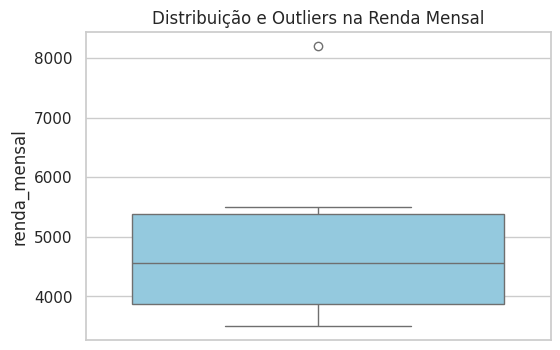

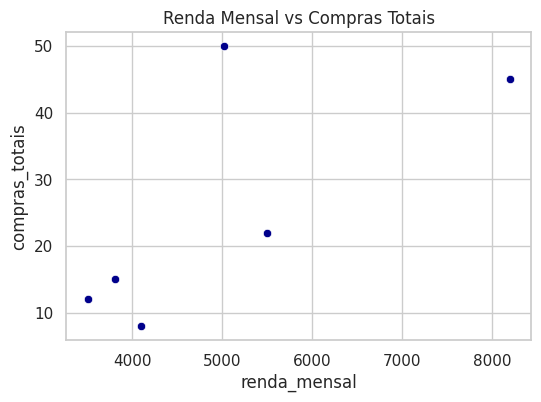

In [27]:
print("--- Tabela de Frequência ---")
print(df['faixa_idade'].value_counts())

# Gráfico 1: Identificando outliers com Boxplot
plt.figure(figsize=(6, 4))
sns.boxplot(y='renda_mensal', data=df, color='skyblue')
plt.title('Distribuição e Outliers na Renda Mensal')
plt.show()

# Gráfico 2: Relação (Correlação) entre variáveis numéricas
plt.figure(figsize=(6, 4))
sns.scatterplot(x='renda_mensal', y='compras_totais', data=df, color='darkblue')
plt.title('Renda Mensal vs Compras Totais')
plt.show()

### 12. Exportação da Base Preparada
Após garantir a qualidade dos dados, é hora de salvar o resultado para a próxima etapa.

In [28]:
# Salvando a base limpa sem o índice para evitar a criação de uma coluna 'Unnamed: 0'
df.to_csv('base_projeto_grupoX.csv', index=False)
print("Base preparada exportada com sucesso!")

Base preparada exportada com sucesso!
